In [20]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Load both CSVs
# ------------------------------------------------------------------
PATH = "../../results/interp/Qwen3-VL-2B-Instruct/das_trial/"
#nat = pd.read_csv(PATH + "das_syntax_target_verb_att0_opp_natural_singular_to_plural.csv")
wug = pd.read_csv(PATH + "probe_syntax_target_verb_att0_opp_bidirectional.csv")

# A = source's good completion (flip target), B = base's good completion
def add_measures(df):
    df = df.copy()
    df["src_diff"]  = df["source_logp_A"] - df["source_logp_B"]            # pre, source
    df["base_diff"] = df["base_logp_A"]   - df["base_logp_B"]              # pre, base
    df["int_diff"]  = df["base_intervention_logp_A"] - df["base_intervention_logp_B"]  # post, base
    # Eq.9 odds: [logp(y_b|b) - logp(y_s|b)] + [logp_f(y_s|b,s) - logp_f(y_b|b,s)]
    #          = (base_B - base_A)           + (int_A - int_B)
    df["odds"] = (df["base_logp_B"] - df["base_logp_A"]) \
               + (df["base_intervention_logp_A"] - df["base_intervention_logp_B"])
    return df

wug = add_measures(wug)

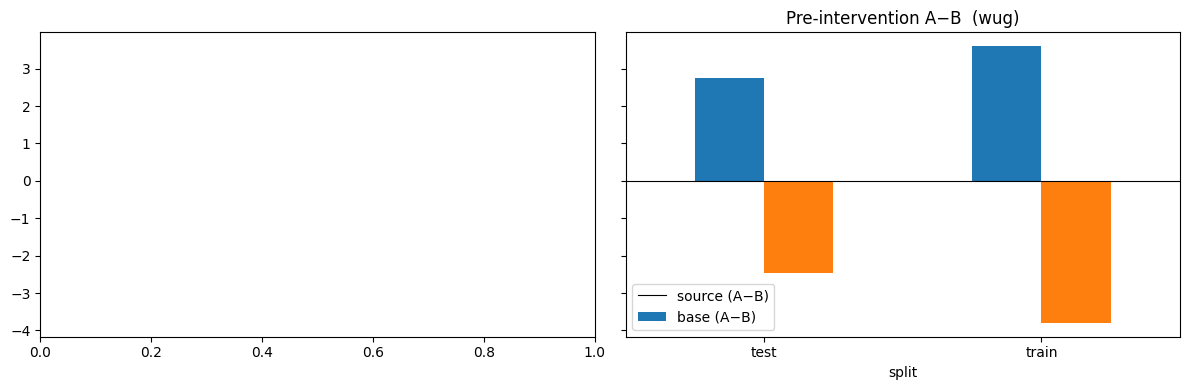

In [22]:
def example_means(df):
    ex = df.drop_duplicates(subset=["split", "source_input", "base_input"])
    return ex.groupby("split")[["src_diff", "base_diff"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, df, name in [(axes[1], wug, "wug")]:
    example_means(df).plot(kind="bar", ax=ax)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"Pre-intervention A−B  ({name})")
    ax.set_ylabel("mean logp(A) − logp(B)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(["source (A−B)", "base (A−B)"])
plt.tight_layout(); plt.show()

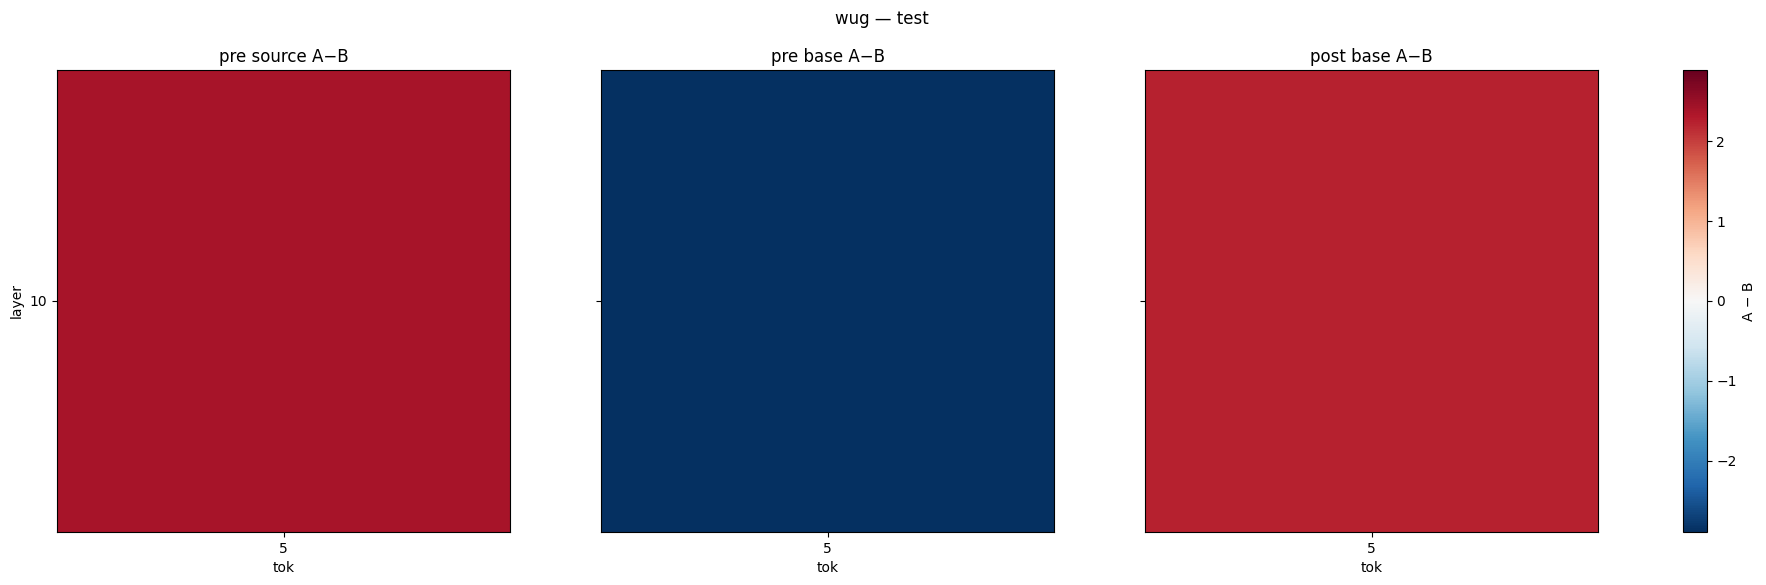

In [23]:
def grid(df, split, col):
    s = df[df["split"] == split]
    return s.groupby(["layer", "tok"])[col].mean().unstack("tok").sort_index()

def heat_triplet(df, split, name):
    pre_src  = grid(df, split, "src_diff")
    pre_base = grid(df, split, "base_diff")
    post     = grid(df, split, "int_diff")
    m = max(abs(pre_src.values).max(), abs(pre_base.values).max(), abs(post.values).max())
    panels = [(pre_src,"pre source A−B"), (pre_base,"pre base A−B"), (post,"post base A−B")]
    fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
    for ax,(mat,t) in zip(axes, panels):
        im = ax.imshow(mat.values, aspect="auto", cmap="RdBu_r", origin="lower", vmin=-m, vmax=m)
        ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns)
        ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
        ax.set_xlabel("tok"); ax.set_title(t)
    axes[0].set_ylabel("layer")
    fig.colorbar(im, ax=axes, label="A − B", fraction=0.046)
    fig.suptitle(f"{name} — {split}")
    plt.show()

#heat_triplet(nat, "test", "natural")
heat_triplet(wug, "test", "wug")

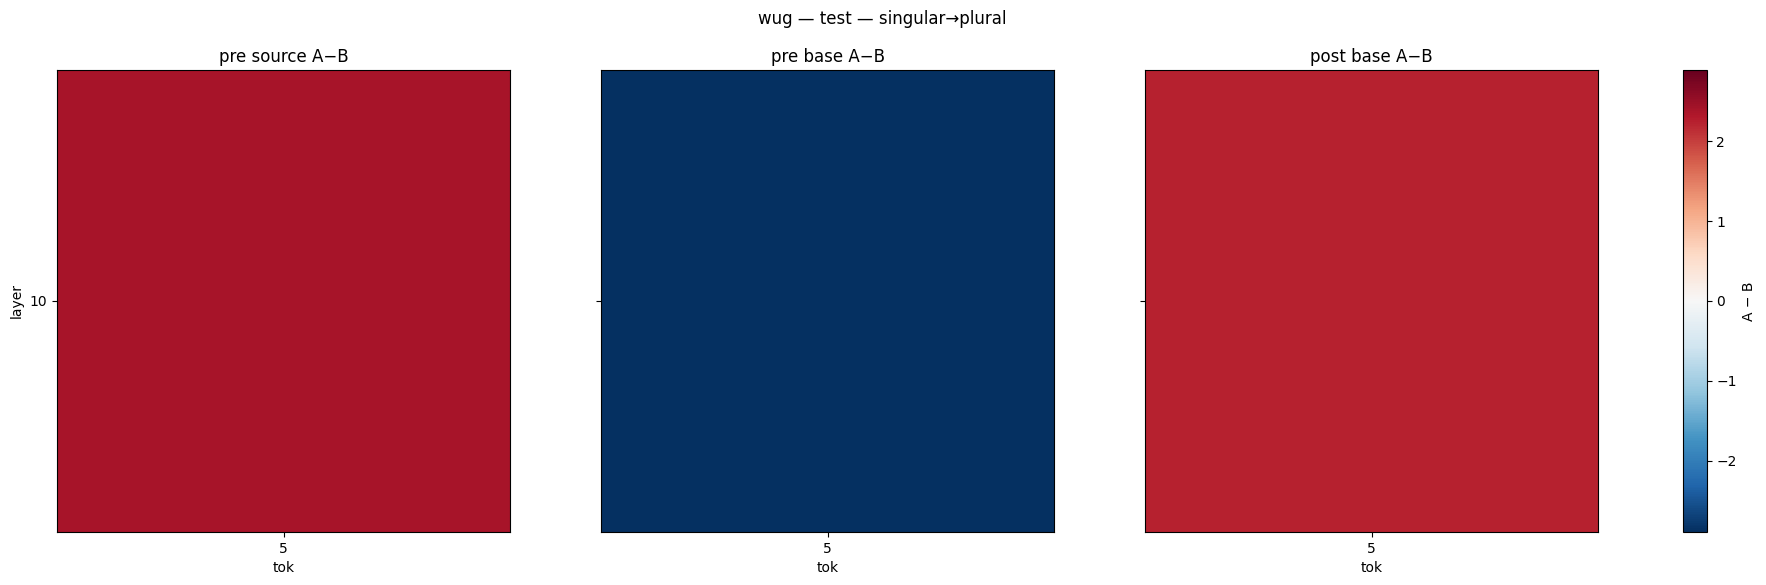

ValueError: zero-size array to reduction operation maximum which has no identity

In [24]:
DIRS = {0: "singular→plural", 1: "plural→singular"}

def grid(df, split, col, inverse):
    s = df[(df["split"] == split) & (df["inverse"] == inverse)]
    return s.groupby(["layer", "tok"])[col].mean().unstack("tok").sort_index()

def heat_triplet(df, split, name, inverse):
    panels = [("src_diff", "pre source A−B"),
              ("base_diff", "pre base A−B"),
              ("int_diff", "post base A−B")]
    mats = [(grid(df, split, c, inverse), t) for c, t in panels]
    m = max(abs(mat.values).max() for mat, _ in mats)

    fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=True)
    for ax, (mat, t) in zip(axes, mats):
        im = ax.imshow(mat.values, aspect="auto", cmap="RdBu_r",
                       origin="lower", vmin=-m, vmax=m)
        ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns)
        ax.set_yticks(range(len(mat.index)));   ax.set_yticklabels(mat.index)
        ax.set_xlabel("tok"); ax.set_title(t)
    axes[0].set_ylabel("layer")
    fig.colorbar(im, ax=axes, label="A − B", fraction=0.046)
    fig.suptitle(f"{name} — {split} — {DIRS[inverse]}")
    plt.show()

for inv in (0, 1):
    heat_triplet(wug, "test", "wug", inv)

In [ ]:
def odds_grid(df, split):
    s = df[df["split"] == split]
    return s.groupby(["layer", "tok"])["odds"].mean().unstack("tok").sort_index()

og_nat, og_wug = odds_grid(nat, "test"), odds_grid(wug, "test")
m = max(abs(og_nat.values).max(), abs(og_wug.values).max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, og, name in [(axes[0], og_nat, "natural"), (axes[1], og_wug, "wug")]:
    im = ax.imshow(og.values, aspect="auto", cmap="RdBu_r", origin="lower", vmin=-m, vmax=m)
    ax.set_xticks(range(len(og.columns))); ax.set_xticklabels(og.columns)
    ax.set_yticks(range(len(og.index)));   ax.set_yticklabels(og.index)
    ax.set_xlabel("tok"); ax.set_title(f"AvgOdds  ({name}, test)")
axes[0].set_ylabel("layer")
fig.colorbar(im, ax=axes, label="log odds-ratio", fraction=0.046)
plt.show()

NameError: name 'nat' is not defined

natural: OverallOdds=7.446  95% CI [7.216, 7.682]
wug: OverallOdds=3.127  95% CI [3.025, 3.229]


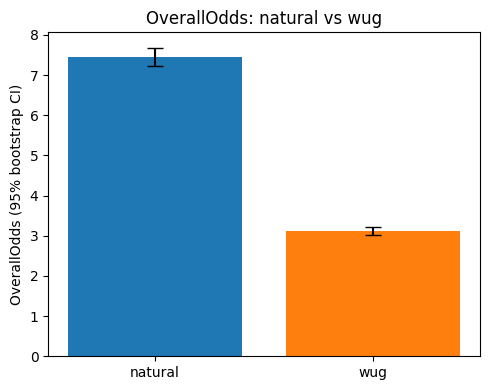

In [ ]:
import numpy as np

def overall_odds_from_long(sub):
    """AvgOdds per (layer,tok) -> max over tok per layer -> mean over layers."""
    og = sub.groupby(["layer", "tok"])["odds"].mean().unstack("tok")
    return og.max(axis=1).mean()

def bootstrap_overall_odds(df, split, n_boot=2000, seed=0):
    s = df[df["split"] == split].copy()
    # example id = the resampling unit
    s["ex"] = s["source_input"] + " ||| " + s["base_input"]
    ex_ids = s["ex"].unique()
    # group rows by example once for fast reassembly
    by_ex = {e: g for e, g in s.groupby("ex")}
    rng = np.random.default_rng(seed)

    point = overall_odds_from_long(s)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        pick = rng.choice(ex_ids, size=len(ex_ids), replace=True)
        resample = pd.concat([by_ex[e] for e in pick], ignore_index=True)
        boots[i] = overall_odds_from_long(resample)

    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi, boots

res = {}
for df, name in [(nat, "natural"), (wug, "wug")]:
    pt, lo, hi, b = bootstrap_overall_odds(df, "test", n_boot=2000)
    res[name] = (pt, lo, hi)
    print(f"{name}: OverallOdds={pt:.3f}  95% CI [{lo:.3f}, {hi:.3f}]")
    import matplotlib.pyplot as plt

names = list(res)
pts = [res[n][0] for n in names]
err = [[res[n][0]-res[n][1] for n in names],   # lower
       [res[n][2]-res[n][0] for n in names]]   # upper
plt.figure(figsize=(5,4))
plt.bar(names, pts, yerr=err, capsize=6, color=["tab:blue","tab:orange"])
plt.ylabel("OverallOdds (95% bootstrap CI)")
plt.title("OverallOdds: natural vs wug")
plt.tight_layout(); plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "../../results/interp/Qwen3-VL-2B-Instruct/"

FILES = [
    "das_syntax_target_verb_att0_opp_natural_singular_to_plural.csv",
    "das_syntax_target_verb_att0_opp_syntax_singular_to_plural.csv",
    "das_syntax_target_verb_att0_opp_plural_to_singular.csv",
    "das_syntax_target_verb_att1_opp_singular_to_plural.csv",
    "das_syntax_target_verb_att2_opp_singular_to_plural.csv",
    "das_vision_target_verb_att0_opp_singular_to_plural.csv",
    "das_vision_target_verb_att0_opp_plural_to_singular.csv",
    "das_vision_target_verb_att1_opp_singular_to_plural.csv",
    "das_vision_target_verb_att2_opp_singular_to_plural.csv",
    "probe_syntax_target_verb_att0_opp_singular_to_plural.csv",
]

def add_measures(df):
    df = df.copy()
    df["src_diff"]  = df["source_logp_A"] - df["source_logp_B"]
    df["base_diff"] = df["base_logp_A"]   - df["base_logp_B"]
    df["int_diff"]  = df["base_intervention_logp_A"] - df["base_intervention_logp_B"]
    df["odds"] = (df["base_logp_B"] - df["base_logp_A"]) \
               + (df["base_intervention_logp_A"] - df["base_intervention_logp_B"])
    return df

def label_from_name(fn):
    """Human label from the filename stem."""
    stem = fn.replace(".csv", "")
    method = "probe" if stem.startswith("probe") else "DAS"
    stream = "vision" if "_vision_" in stem else "syntax"
    att = next((p for p in stem.split("_") if p.startswith("att")), "att?")
    direction = "sg→pl" if "singular_to_plural" in stem else "pl→sg"
    # the natural/syntax tag (only present on the two att0 syntax files)
    extra = ""
    if "_natural_" in stem: extra = " [natural-test]"
    elif "_syntax_singular" in stem: extra = " [wug-test]"
    return f"{method} | {stream} | {att} | {direction}{extra}"

data = {fn: add_measures(pd.read_csv(PATH + fn)) for fn in FILES}

def odds_grid(df, split):
    s = df[df["split"] == split]
    if s.empty:
        return None
    return s.groupby(["layer", "tok"])["odds"].mean().unstack("tok").sort_index()

/tmp/ipykernel_3744281/1327677030.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


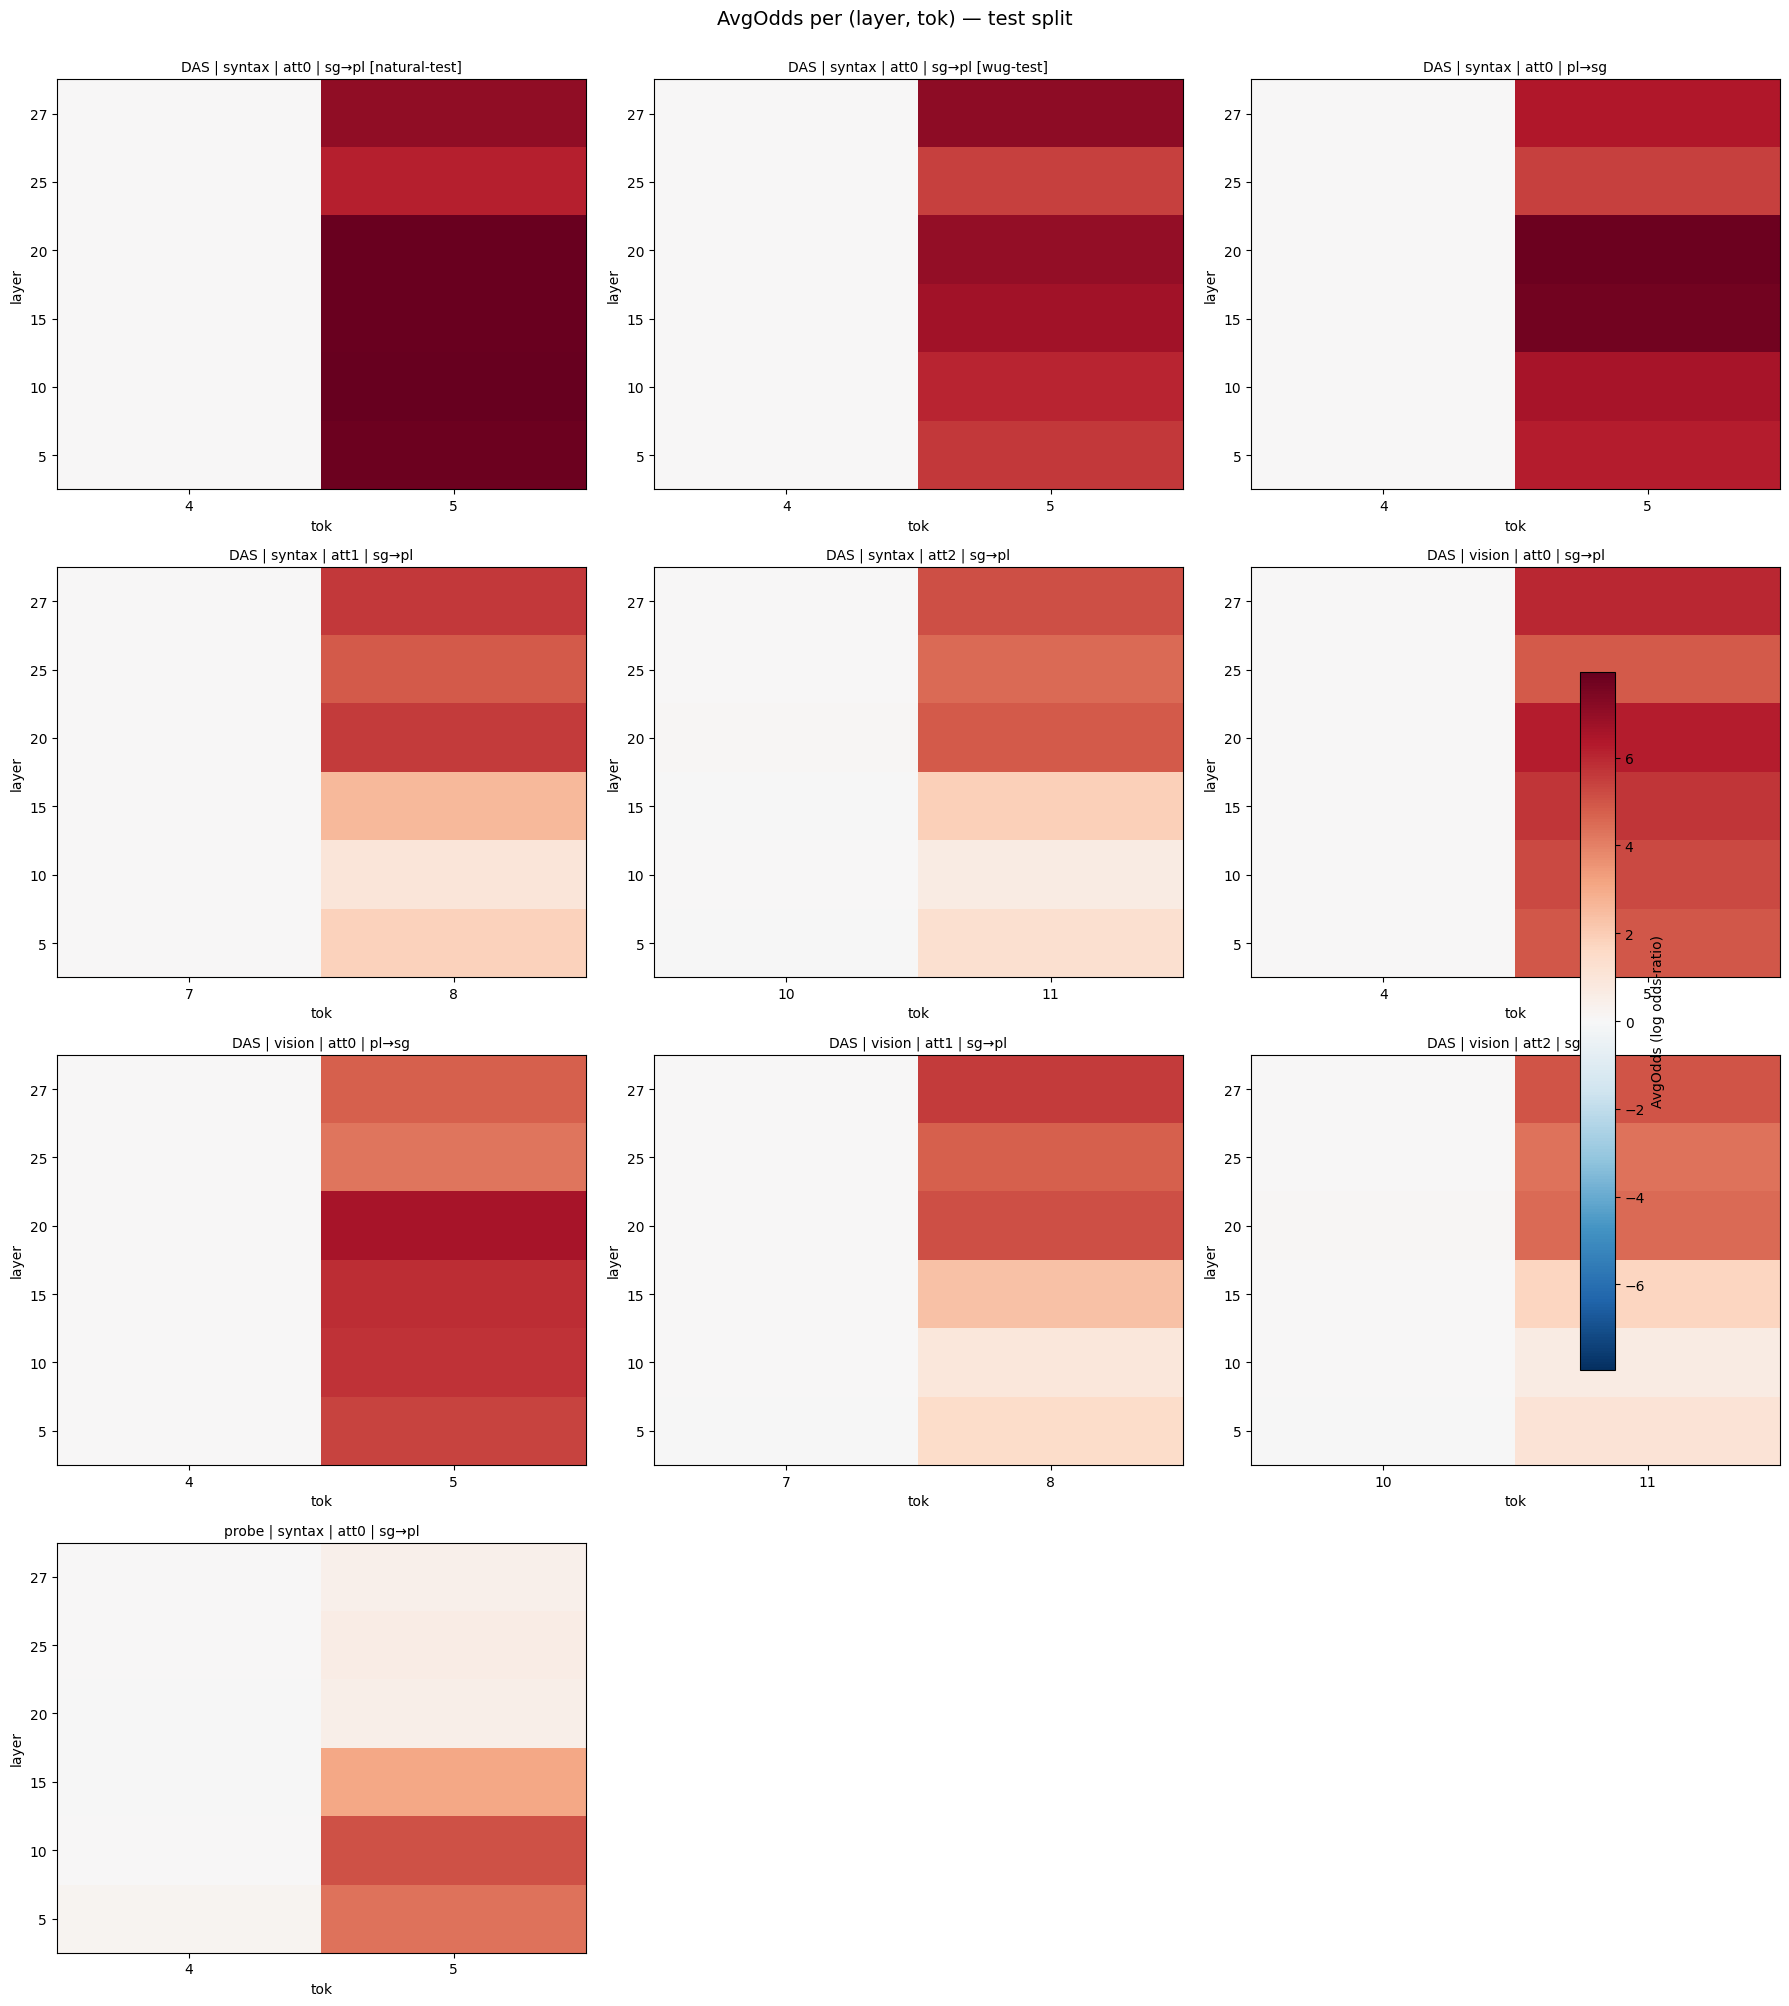

In [ ]:
SPLIT = "test"   # transfer measure; switch to "train" for in-sample

grids = {fn: odds_grid(df, SPLIT) for fn, df in data.items()}
grids = {fn: g for fn, g in grids.items() if g is not None}   # drop empty test splits

m = max(abs(g.values).max() for g in grids.values())          # shared scale

n = len(grids)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, (fn, g) in zip(axes, grids.items()):
    im = ax.imshow(g.values, aspect="auto", cmap="RdBu_r",
                   origin="lower", vmin=-m, vmax=m)
    ax.set_xticks(range(len(g.columns))); ax.set_xticklabels(g.columns)
    ax.set_yticks(range(len(g.index)));   ax.set_yticklabels(g.index)
    ax.set_xlabel("tok"); ax.set_ylabel("layer")
    ax.set_title(label_from_name(fn), fontsize=10)

for ax in axes[n:]:        # hide unused panels
    ax.axis("off")

fig.colorbar(im, ax=axes.tolist(), label="AvgOdds (log odds-ratio)",
             fraction=0.025)
fig.suptitle(f"AvgOdds per (layer, tok) — {SPLIT} split", y=1.001, fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def overall_odds_from_long(sub):
    """AvgOdds per (layer,tok) -> max over tok per layer -> mean over layers."""
    og = sub.groupby(["layer", "tok"])["odds"].mean().unstack("tok")
    return og.max(axis=1).mean()

def bootstrap_overall_odds(df, split, n_boot=2000, seed=0):
    s = df[df["split"] == split].copy()
    if s.empty:
        return None
    s["ex"] = s["source_input"] + " ||| " + s["base_input"]
    ex_ids = s["ex"].unique()
    by_ex = {e: g for e, g in s.groupby("ex")}
    rng = np.random.default_rng(seed)

    point = overall_odds_from_long(s)
    boots = np.empty(n_boot)
    for i in range(n_boot):
        pick = rng.choice(ex_ids, size=len(ex_ids), replace=True)
        resample = pd.concat([by_ex[e] for e in pick], ignore_index=True)
        boots[i] = overall_odds_from_long(resample)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return point, lo, hi

SPLIT = "test"

res = {}
for fn, df in data.items():
    out = bootstrap_overall_odds(df, SPLIT, n_boot=2000)
    if out is None:
        print(f"SKIP (empty {SPLIT}): {fn}")
        continue
    res[label_from_name(fn)] = out
    pt, lo, hi = out
    print(f"{label_from_name(fn):42s} OverallOdds={pt:.3f}  CI [{lo:.3f}, {hi:.3f}]")

DAS | syntax | att0 | sg→pl [natural-test] OverallOdds=7.446  CI [7.216, 7.682]
DAS | syntax | att0 | sg→pl [wug-test]     OverallOdds=6.300  CI [5.773, 6.791]
DAS | syntax | att0 | pl→sg                OverallOdds=6.667  CI [6.279, 6.997]
DAS | syntax | att1 | sg→pl                OverallOdds=3.559  CI [3.445, 3.678]
DAS | syntax | att2 | sg→pl                OverallOdds=3.051  CI [2.950, 3.149]
DAS | vision | att0 | sg→pl                OverallOdds=5.486  CI [5.047, 5.860]
DAS | vision | att0 | pl→sg                OverallOdds=5.427  CI [5.051, 5.778]
DAS | vision | att1 | sg→pl                OverallOdds=3.367  CI [3.257, 3.475]
DAS | vision | att2 | sg→pl                OverallOdds=2.877  CI [2.777, 2.974]
probe | syntax | att0 | sg→pl              OverallOdds=2.315  CI [2.157, 2.497]


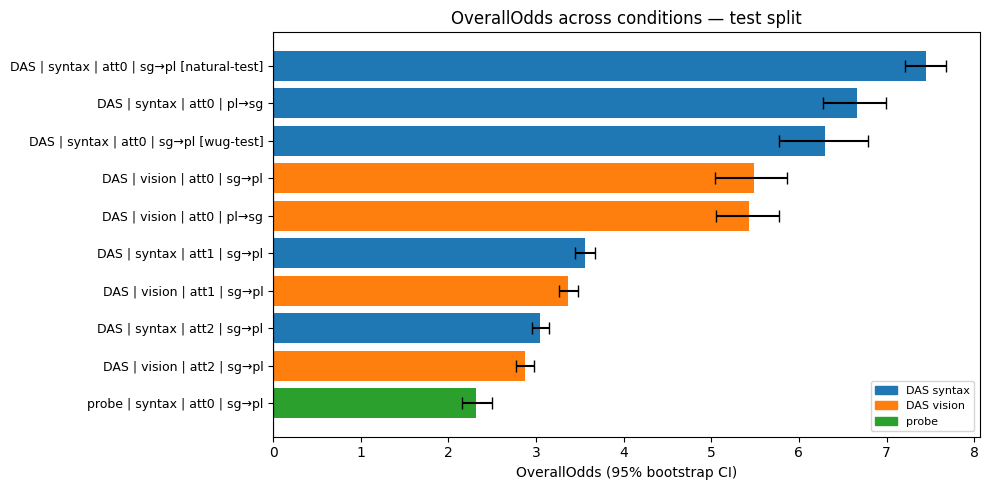

In [ ]:
# sort by point estimate, descending
items = sorted(res.items(), key=lambda kv: kv[1][0], reverse=True)
labels = [k for k, _ in items]
pts = [v[0] for _, v in items]
lo  = [v[1] for _, v in items]
hi  = [v[2] for _, v in items]
err = [[p - l for p, l in zip(pts, lo)],     # lower
       [h - p for p, h in zip(pts, hi)]]     # upper

# color by stream/method for quick reading
def bar_color(lbl):
    if lbl.startswith("probe"): return "tab:green"
    return "tab:orange" if "vision" in lbl else "tab:blue"
colors = [bar_color(l) for l in labels]

fig, ax = plt.subplots(figsize=(10, max(4, 0.5 * len(labels))))
y = np.arange(len(labels))
ax.barh(y, pts, xerr=err, capsize=4, color=colors)
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()                       # largest on top
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("OverallOdds (95% bootstrap CI)")
ax.set_title(f"OverallOdds across conditions — {SPLIT} split")

# legend for the color scheme
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="tab:blue", label="DAS syntax"),
                   Patch(color="tab:orange", label="DAS vision"),
                   Patch(color="tab:green", label="probe")],
          loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()